##  Step 1: Import libraries

In [32]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

## Step 2: Load dataset

In [33]:
df = pd.read_csv("../data/processed/train_final.csv")

## Step 3: Prepare X and y

In [34]:
X = df.drop("FloodProbability", axis=1)
y = df["FloodProbability"]

# Convert to binary
threshold = y.median()
y = (y >= threshold).astype(int)

## Step 4: Train-test split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Step 5: Scaling (same as before)

In [36]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 6: Sigmoid function

In [37]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

## Step 7: Initialize parameters

In [38]:
weights = np.zeros(X_train.shape[1])
bias = 0

## Step 8: Training (Gradient Descent)

In [39]:
# Step 8: Training (Gradient Descent + Loss Tracking)

learning_rate = 0.01
epochs = 2000

losses = []   # <-- ADD THIS

for i in range(epochs):
    
    linear_model = np.dot(X_train, weights) + bias
    y_pred = sigmoid(linear_model)

    # Compute loss (binary cross-entropy)
    loss = -np.mean(
        y_train * np.log(y_pred + 1e-9) + 
        (1 - y_train) * np.log(1 - y_pred + 1e-9)
    )
    losses.append(loss)   # <-- ADD THIS

    # gradients
    dw = (1 / len(X_train)) * np.dot(X_train.T, (y_pred - y_train))
    db = (1 / len(X_train)) * np.sum(y_pred - y_train)

    # update
    weights -= learning_rate * dw
    bias -= learning_rate * db

## Plot loss

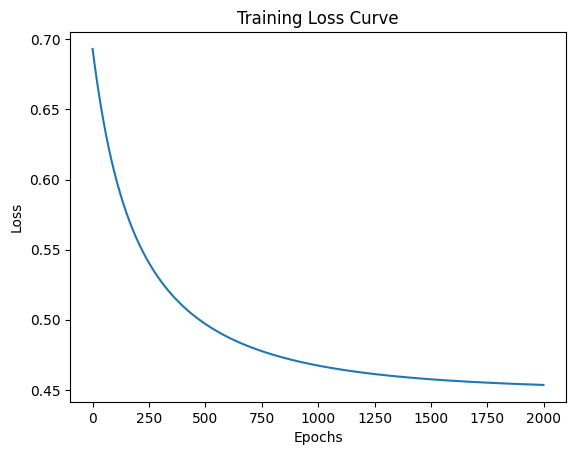

In [40]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

## Step 9: Prediction

In [41]:
linear_test = np.dot(X_test, weights) + bias
y_pred_scratch = sigmoid(linear_test)

# convert to class
y_pred_scratch = (y_pred_scratch >= 0.5).astype(int)

In [42]:
from sklearn.metrics import roc_auc_score

y_prob_scratch = sigmoid(linear_test)
auc_score = roc_auc_score(y_test, y_prob_scratch)

print("Scratch ROC-AUC:", auc_score)

Scratch ROC-AUC: 0.8684443152260903


## Step 10: Evaluate scratch model

In [43]:
print("Scratch Model Accuracy:", accuracy_score(y_test, y_pred_scratch))
print(classification_report(y_test, y_pred_scratch))

Scratch Model Accuracy: 0.780125
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      3920
           1       0.79      0.78      0.78      4080

    accuracy                           0.78      8000
   macro avg       0.78      0.78      0.78      8000
weighted avg       0.78      0.78      0.78      8000



## Step 11: Sklearn model

In [44]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)

print("Sklearn Model Accuracy:", accuracy_score(y_test, y_pred_sklearn))

Sklearn Model Accuracy: 0.781625


## Step 12: Final comparison

In [45]:
print("Scratch vs Sklearn difference:")
print("Scratch:", accuracy_score(y_test, y_pred_scratch))
print("Sklearn:", accuracy_score(y_test, y_pred_sklearn))

Scratch vs Sklearn difference:
Scratch: 0.780125
Sklearn: 0.781625
